# DA5401W: Data Analytics Lab
### Mid Term Examination - March 8th, 2026
#### Optimization, Dimensionality Reduction, Clustering & Regression

**Course:** DA5401W — Data Analytics Lab

**Student Name:** Sohang Chopra

**Student ID:** DA25M622

---

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| Q1 | SciPy Optimisation | 5 |
| Q2 | PCA | 5 |
| Q3 | K-Means Clustering | 5 |
| Q4 | Agglomerative Clustering | 5 |
| Q5 | DBSCAN | 5 |
| Q6 | Linear Regression | 5 |
| **Total** | | **30** |


## Instructions

- This exam is worth **30 marks** in total.
- Run the **Setup** cell first before attempting any question.
- Store your results in the **exact variable names** specified in each question — these are used for auto-grading.
- Written answers must be entered in the designated grey answer cells.
- Do **not** rename or delete any cells.
- **Use of LLMs for generation of Code is strictly prohibited**. IF there is evidence of using LLMS .e.g. chatgpt, claude code, etc for coding then strict action will be taken

## Setup — Run this cell first, do not modify


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

# Load dataset — works on Google Colab and local Otter Grader
import os
if os.path.exists('city_data.csv'):
    df = pd.read_csv('city_data.csv')
else:
    df = pd.read_csv('https://drive.google.com/uc?export=download&id=13mv-92pnMU-GyO1RWkprBeIUT-p1pifK')

features = ['gdp_per_capita', 'unemployment_rate', 'literacy_rate',
            'healthcare_index', 'green_space_pct', 'public_transport_score',
            'internet_penetration', 'crime_index']
X_raw = df[features].copy()
y = df['qol_index'].copy()
print(f'Dataset loaded: {df.shape[0]} cities, {len(features)} features')
print(f'Target (QoL Index) range: {y.min():.2f} to {y.max():.2f}')


Dataset loaded: 500 cities, 8 features
Target (QoL Index) range: 28.08 to 81.25


---
## Q1: SciPy Optimisation (5 marks)


### Q1a — Unconstrained Minimisation `[2 marks]`

A city planner wants to minimise the following cost function:

$$f(x_1, x_2) = (x_1 - 3)^2 + 2(x_2 - 2)^2 + x_1 x_2$$

Minimise $f(x_1, x_2)$ using `scipy.optimize.minimize` with `method='BFGS'`, starting from $x_0 = [0, 0]$. Print the optimal point and minimum value.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `opt_x1_unc` | `float` | Optimal value of x1 |
| `opt_x2_unc` | `float` | Optimal value of x2 |



In [95]:
# Q1a: Unconstrained minimisation (BFGS)
# Graded: opt_x1_unc, opt_x2_unc
x0 = np.array([0,0])
objective = lambda x: (x[0] - 3)**2 + 2 * (x[1] - 2)**2 + x[0] * x[1]
obj_gradient = lambda x: np.array([2*(x[0] - 3) + x[1], 2*(x[1] - 2) + x[0]])
result = minimize(objective, x0, jac=obj_gradient, method='BFGS')
opt_x1_unc = float(result.x[0])
opt_x2_unc = float(result.x[1])
print('Optimal Point:', result.x)
print('Minimum Value:', result.fun)

Optimal Point: [2.6664368  0.66709635]
Minimum Value: 5.44329893638033


### Q1b — Constrained Minimisation `[2 marks]`

Add the equality constraint $x_1 + x_2 = 4$ (total budget units) and re-solve using `method='SLSQP'`. Print the constrained solution and compare with Q1a.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `opt_x1_con` | `float` | Constrained optimal x1 |
| `opt_x2_con` | `float` | Constrained optimal x2 |



In [96]:
# Q1b: Constrained minimisation (SLSQP) with x1 + x2 = 4
# Graded: opt_x1_con, opt_x2_con
from scipy.optimize import LinearConstraint
result = minimize(objective, x0, jac=obj_gradient, method='SLSQP', constraints=[LinearConstraint(np.array([1,1]), 4, 4)])
opt_x1_con = float(result.x[0])
opt_x2_con = float(result.x[1])
print('Optimal Point:', result.x)
print('Minimum Value:', result.fun)

Optimal Point: [3. 1.]
Minimum Value: 5.0


BFGS' unconstrained optimal point does not satisfy linear constraint $x1 + x2 = 4$. SLSQP has found a solution satisfying linear constraint, and its minimum value is also better than BFGS solution. So SLSQP is more accurate algorithm than BFGS in this case.

### Q1c — Linear Programming `[1 mark]`

A regional government allocates budget across three programmes. Use `scipy.optimize.linprog` to solve:

**Maximise:** $5H + 4E + 3I$ (social benefit)  
**Subject to:**  
- $6H + 4E + 2I \leq 240$ (budget constraint, million USD)  
- $3H + 2E + 5I \leq 270$ (workforce constraint, thousand staff)  
- $H, E, I \geq 0$

Print the optimal allocation and maximum social benefit.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `lp_benefit` | `float` | Maximum social benefit (positive value) |



In [97]:
# Q1c: Linear programming (linprog) — maximise social benefit
# Graded: lp_benefit
c = np.array([-5, -4, -3])   # converts maximize constraint to minimize
A_ub = np.array([[6,4,2], [3,2,5]])
b_ub = np.array([240,270])
result = linprog(c=c, A_ub=A_ub, b_ub=b_ub)
lp_benefit = float(-result.fun)
print('Optimal Point (H,E,I):', result.x)
print('Maximum Value:', lp_benefit)


Optimal Point (H,E,I): [ 0.   41.25 37.5 ]
Maximum Value: 277.5


---
## Q2: Principal Component Analysis (5 marks)


### Q2a — Explained Variance `[2 marks]`

Standardise the 8 features using `StandardScaler`. Fit a **full PCA** (all 8 components) on the standardised data. Print the explained variance ratio for each component and state how many components are needed to explain at least **80%** of the total variance.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `X_scaled` | `ndarray` (500, 8) | Standardised feature matrix |
| `n_components` | `int` | Number of components explaining ≥ 80% variance |



In [17]:
# Q2a: Standardise, fit full PCA, determine n_components
# Graded: X_scaled, n_components
X_scaled = StandardScaler().fit_transform(X_raw)
pca_full = PCA().fit(X_scaled)
print('Explained Variance Ratios:', pca_full.explained_variance_ratio_)
n_components = 3


Explained Variance Ratios: [0.71318782 0.06179522 0.05408035 0.04615381 0.03658557 0.03442849
 0.02805708 0.02571165]


3 Principal Components explain >= 80% variance by looking at explained variance ratios

### Q2b — Dimensionality Reduction `[1 mark]`

Reduce the data to `n_components` components using a new PCA object. Print the shape of the reduced data and the exact percentage of total variance retained.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `X_pca` | `ndarray` (500, n_components) | PCA-reduced data — **used in Q3–Q6** |



In [20]:
# Q2b: Reduce to n_components, store as X_pca
# Graded: X_pca
pca_nd = PCA(n_components=n_components).fit(X_scaled)
X_pca = pca_nd.transform(X_scaled)
print('Shape of reduced data:', X_pca.shape)
print(f'Percentage of total variance retained: {pca_nd.explained_variance_ratio_.sum() :.2%}')


Shape of reduced data: (500, 3)
Percentage of total variance retained: 82.91%


### Q2c — Reconstruction Error `[2 marks]`

Use `pca_nd.inverse_transform()` to reconstruct the original standardised data from `X_pca`. Compute the **mean squared reconstruction error** between the original standardised data (`X_scaled`) and the reconstructed data.

Print the reconstruction error and write one sentence explaining what this value tells you about the information lost during dimensionality reduction.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `reconstruction_error` | `float` | Mean squared error between `X_scaled` and its PCA reconstruction |


In [21]:
# Q2c: Reconstruct data and compute mean squared reconstruction error
# Graded: reconstruction_error
X_reconstructed = pca_nd.inverse_transform(X_pca)
reconstruction_error = mean_squared_error(X_reconstructed, X_scaled)
print('Reconstruction Error:', reconstruction_error)

Reconstruction Error: 0.17093660326769303


**Q2c — What does the reconstruction error tell you? — Written answer:**

> *Reconstruction Error 17% is lost variance, which matches approximately 100% - 82% (total explained variance of PCA)*


---
## Q3: K-Means Clustering (5 marks)

> Use `X_pca` from Q2 for all clustering questions.


### Q3a — Choosing k `[2 marks]`

Run K-Means for **k = 2 to 8**. For each k, record the inertia and silhouette score. Print a table of k, inertia, and silhouette score. Plot the **silhouette score vs k**. Choose the best k and print a one-sentence justification.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `sil_scores` | `list` of 7 floats | Silhouette scores for k = 2, 3, …, 8 |
| `best_k` | `int` | Chosen number of clusters |



   k      inertia  silhoutte_score
0  2  1448.417377         0.468287
1  3   605.929676         0.546476
2  4   571.736838         0.460881
3  5   453.782056         0.339362
4  6   453.211307         0.342835
5  7   389.452884         0.316810
6  8   354.822545         0.245587


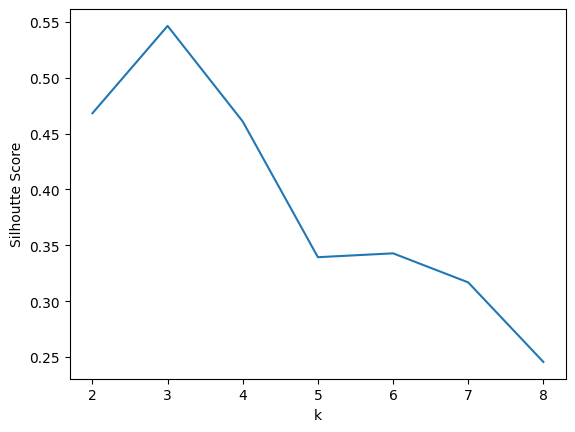

In [46]:
# Q3a: K-Means for k=2 to 8, silhouette plot
# Graded: sil_scores, best_k
inertias = []
sil_scores = []
k_values = np.arange(2,9)
for k in k_values:
  kmeans = KMeans(n_clusters=k).fit(X_pca)
  inertias.append(kmeans.inertia_)
  sil_scores.append(silhouette_score(X_pca, kmeans.labels_))
print(pd.DataFrame({'k': k_values, 'inertia': inertias, 'silhoutte_score': sil_scores}))

plt.plot(k_values, sil_scores)
plt.xlabel('k')
plt.ylabel('Silhoutte Score')
plt.show()

best_k = 3      # since silhoutte score plot peaks at this k


### Q3b — Fit K-Means `[1 mark]`

Fit K-Means with your chosen `best_k` on `X_pca`. Print the number of cities in each cluster.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `kmeans_labels` | `ndarray` (500,) | Cluster label for each city — **used in Q6** |



In [30]:
# Q3b: Fit K-Means with best_k
# Graded: kmeans_labels
kmeans_labels = KMeans(n_clusters=best_k).fit_predict(X_pca)
print('No. of cities in each cluster:', pd.Series(kmeans_labels).value_counts(), sep='\n')


No. of cities in each cluster:
2    211
1    175
0    114
Name: count, dtype: int64


### Q3c — Cluster Profiles `[2 marks]`

Compute the mean value of each original feature per cluster. Print the summary table. Write one sentence describing what type of city each cluster represents.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `km_summary` | `DataFrame` | Mean features per cluster (rows = clusters, cols = features) |



In [34]:
# Q3c: Mean feature values per cluster
# Graded: km_summary
km_summary = X_raw.groupby(kmeans_labels).mean()
km_summary

,gdp_per_capita,unemployment_rate,literacy_rate,healthcare_index,green_space_pct,public_transport_score,internet_penetration,crime_index
0,84364.982456,4.537105,93.976404,77.820965,22.852544,73.916316,87.776579,34.003421
1,21699.897143,11.974857,69.043314,38.827543,9.090000,29.108114,44.153714,61.953029
2,44860.587678,7.583602,81.602654,58.004929,14.643412,50.398768,68.214265,47.506730


**Q3c — Describe each cluster in one sentence — Written answer:**

1. Cluster 0: **Rich Tier-1 Metropolitan City** due to High `gdp_per_capita, literacy_rate, healthcare_index, green_space_pct, public_transport_score, internet_penetration`, Low `unemployment_rate, crime_rate`

2. Cluster 1: **Poor Tier-3 city**: Low `gdp_per_capita, literacy_rate, healthcare_index, green_space_pct, public_transport_score, internet_penetration`, High `unemployment_rate, crime_index`

3. Cluster 2: **Tier-2 city**: all feature means are Medium (between clusters 0, 1)

---
## Q4: Agglomerative Clustering (5 marks)
> Use `X_pca` from Q2 and `best_k` from Q3.


### Q4a — Fit Agglomerative Clustering `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` and `linkage='ward'` on `X_pca`.

Print the number of cities in each cluster.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `agg_labels` | `np.ndarray` | Cluster label for each city (0-indexed) |


In [102]:
# Q4a: Fit AgglomerativeClustering with ward linkage
# Graded: agg_labels
agg_labels = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit_predict(X_pca)
print('No. of cities in each cluster:', pd.Series(agg_labels).value_counts(), sep='\n')


No. of cities in each cluster:
0    216
1    171
2    113
Name: count, dtype: int64


### Q4b — Compare Linkage Methods `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` for **three linkage methods**: `'ward'`, `'complete'`, and `'average'`.

For each, compute and print the **silhouette score**. Store the name of the linkage method with the highest silhouette score.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `best_linkage` | `str` | Name of the linkage method with the highest silhouette score |


In [37]:
# Q4b: Compare ward, complete, average linkage methods
# Graded: best_linkage
for linkage in ['ward', 'complete', 'average']:
  agg_labels = AgglomerativeClustering(n_clusters=best_k, linkage=linkage).fit_predict(X_pca)
  print(f'Silhouette Score for {linkage} linkage:', silhouette_score(X_pca, agg_labels))
best_linkage = 'complete'

Silhouette Score for ward linkage: 0.538708056797509
Silhouette Score for complete linkage: 0.5417235949700974
Silhouette Score for average linkage: 0.5323191376609477


### Q4c — Comparison `[1 mark]`

State **one advantage** of agglomerative clustering over K-Means and **one disadvantage**. Write your answer in the cell below.


**Q4c — One advantage and one disadvantage of agglomerative clustering vs K-Means — Written answer:**

**Advantage**: Agglomerative Clustering can handle clusters with varying density, whereas K-Means assumes all clusters are spherical with similar densities.

**Disadvantage**: Agglomerative Clustering is slower than K-Means.


---
## Q5: DBSCAN (5 marks)

> Use `X_pca` from Q2.


### Q5a — Choosing eps `[2 marks]`

Fit a `NearestNeighbors` model with `n_neighbors=4` on `X_pca`. Sort the 4th-nearest-neighbour distances in **descending order** and plot the k-distance curve. Identify the elbow point and state your chosen `eps` value with a one-sentence justification.

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `k_distances` | `ndarray` (500,) | Sorted 4th-NN distances (descending) |
| `eps_chosen` | `float` | Your chosen eps value |



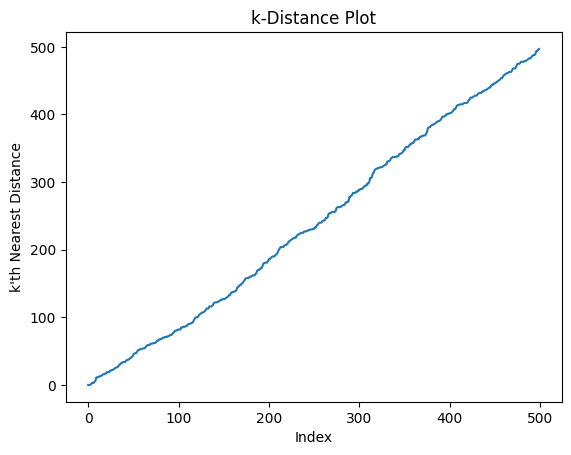

In [51]:
# Q5a: k-distance plot (k=4), choose eps
# Graded: k_distances, eps_chosen
k = 4
nbrs = NearestNeighbors(n_neighbors=4).fit(X_pca)
indices, distances = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, k-1], axis=0)

plt.plot(k_distances)
plt.title('k-Distance Plot')
plt.xlabel('Index')
plt.ylabel("k'th Nearest Distance")
plt.show()

eps_chosen = 0.5    # k-distance plot has no elbow. So using default eps=0.5 of DBSCAN


### Q5b — Fit DBSCAN `[1 mark]`

Fit DBSCAN with `eps=eps_chosen` and `min_samples=5` on `X_pca`. Print the number of clusters found (excluding noise) and the number of noise points.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `n_clusters_db` | `int` | Number of clusters found (excluding noise) |



In [103]:
# Q5b: Fit DBSCAN
# Graded: n_clusters_db
dbscan = DBSCAN(eps=eps_chosen, min_samples=5).fit(X_pca)
n_clusters_db = int(1 + np.max(dbscan.labels_[dbscan.labels_ != -1]))    # 1+ to convert 0-based index to 1-based
print('No. of clusters (excluding noise):', n_clusters_db)
print('No. of noise points:', (dbscan.labels_ == -1).sum())

No. of clusters (excluding noise): 3
No. of noise points: 82


### Q5c — Cluster Profiles & Comparison `[2 marks]`

Print the mean feature values per DBSCAN cluster, **excluding noise points** (label = -1). Then state one scenario where DBSCAN is preferable to K-Means and one where it is not.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `db_summary` | `DataFrame` | Mean features per DBSCAN cluster, noise excluded |



In [64]:
# Q5c: Mean features per DBSCAN cluster (excl. noise)
# Graded: db_summary
db_summary = X_raw.groupby(dbscan.labels_).mean()
db_summary = db_summary[db_summary.index != -1]
db_summary        # indices are DBSCAN cluster labels

,gdp_per_capita,unemployment_rate,literacy_rate,healthcare_index,green_space_pct,public_transport_score,internet_penetration,crime_index
0,45385.807910,7.507740,81.906780,58.673164,14.748531,50.684237,68.013616,47.927006
1,85160.255319,4.628404,94.171596,77.912021,22.973191,74.003404,87.809043,35.450532
2,21941.659864,12.097755,68.746327,38.735170,8.994830,28.778912,43.865578,61.428299


**Q5c — When is DBSCAN better than K-Means, and when is it not? — Written answer:**

DBSCAN is better than K-Means in case of non-spherical clusters - for example, concentric circles.

DBSCAN is worse than K-Means in case of spherical clusters because it is slower than K-Means.


---
## Q6: Linear Regression (5 marks)


### Q6a — Baseline Model `[1 mark]`

Split the data **80/20** (`random_state=42`). Standardise the features (fit scaler on train only, transform both). Train a `LinearRegression` model on the **raw 8 features**. Print RMSE and R² on the test set.

**Graded variable:**

| Variable | Type | Description |
|---|---|---|
| `r2_base` | `float` | R² score on test set |



In [92]:
# Q6a: Baseline LinearRegression on raw features
# Graded: r2_base
# (also store X_train, X_test, y_train, y_test for use in Q6b)
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
train_indices, test_indices = train_test_split(np.arange(y.shape[0]), train_size=0.8, random_state=42)
X_train, X_test, y_train, y_test = X_raw.iloc[train_indices], X_raw.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_pred = linreg.predict(X_test)
r2_base = r2_score(y_test, y_pred)
print('RMSE on Test data:', root_mean_squared_error(y_test, y_pred))
print('R^2 on Test data:', r2_base)


RMSE on Test data: 3.002558509293507
R^2 on Test data: 0.9429619820538522


### Q6b — Pipeline Model `[2 marks]`

Build a combined feature matrix by concatenating the **PCA components** (`X_pca`) with **one-hot encoded K-Means cluster labels** (`kmeans_labels`). Train a second `LinearRegression` on this combined matrix using the same 80/20 split. Print RMSE and R².

**Graded variables:**

| Variable | Type | Description |
|---|---|---|
| `rmse_pipe` | `float` | RMSE on test set |
| `r2_pipe` | `float` | R² on test set |



In [93]:
# Q6b: LinearRegression on PCA + one-hot cluster features
# Graded: rmse_pipe, r2_pipe
one_hot_labels = np.array([(kmeans_labels == i) for i in range(best_k)]).T
X_pipe = np.hstack([X_pca, one_hot_labels])
X_train_pipe, X_test_pipe = X_pipe[train_indices], X_pipe[test_indices]
linreg_pipe = LinearRegression().fit(X_train_pipe, y_train)
y_pred_pipe = linreg_pipe.predict(X_test_pipe)
rmse_pipe = root_mean_squared_error(y_test, y_pred_pipe)
r2_pipe = r2_score(y_test, y_pred_pipe)
print('RMSE of combined model:', rmse_pipe)
print('R^2 of combined model:', r2_pipe)

RMSE of combined model: 3.412649506558913
R^2 of combined model: 0.9263174171923577


### Q6c — Interpretation `[2 marks]`

Print the coefficients of both models as a table. Then explain in **3–4 sentences** why the second model performs differently from the baseline and what role the cluster labels play.


In [91]:
# Q6c: Print coefficients of both models
# (Written explanation goes in the answer cell below)
print(f'Baseline model: Coefficients={linreg.coef_}, Intercept={linreg.intercept_}')
print(f'Pipe model: Coefficients={linreg_pipe.coef_}, Intercept={linreg_pipe.intercept_}')

Baseline model: Coefficients=[ 5.01194905 -1.21388062  1.62672831  2.21940111  1.5567734   2.11408996
  0.0983295  -1.16484831], Intercept=51.987175
Pipe model: Coefficients=[ 5.31762826  0.30836204 -0.58310168  0.42910484  0.17224095 -0.6013458 ], Intercept=52.00830668227379


**Q6c — Why does the pipeline model perform differently? What do cluster labels contribute? — Written answer:**

Usually PCA + cluster labels combination should improve model performance, since PCA and clustering both add non-linear information to the data, which helps linear regression model as it can normally only find linear relationships. But in this case RMSE, R^2 score are both slightly worse in pipeline model, suggesting there is too much error in PCA & cluster labels which degrades performance.
